In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

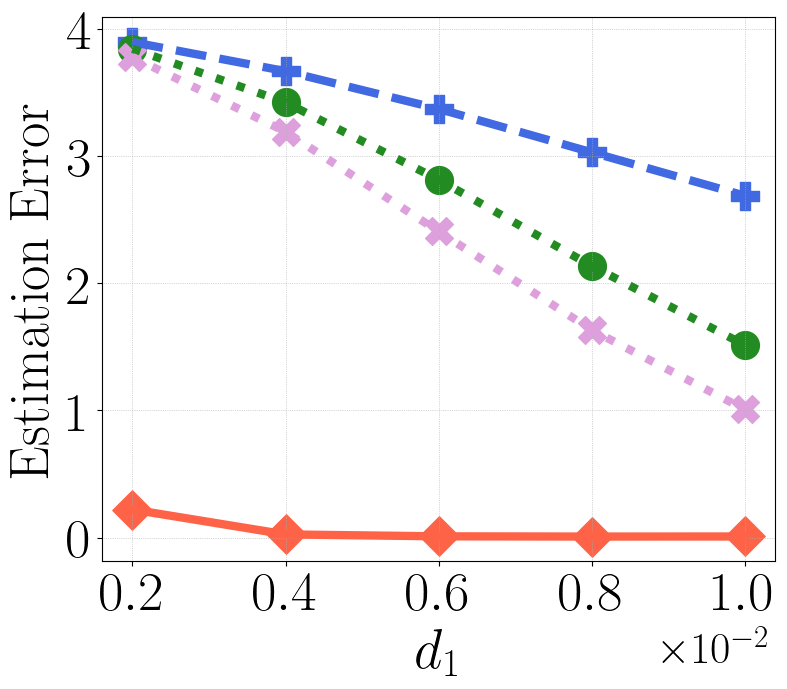

In [ ]:
p = [0.002, 0.004, 0.006, 0.008, 0.01]
alt_GD = np.array([148.2604431, 32.0492641, 16.5793007, 9.6074617, 4.9635245])
softimpute_als = np.array([3.8955405, 3.6670523, 3.3708493, 3.0292181, 2.6883306])
nuclear_reg = np.array([3.8431460, 3.4214577, 2.8141486, 2.1356486, 1.5148298])
iipw_1 = np.array([3.7779362, 3.1910096, 2.4069012, 1.6331401, 1.0081587])
iipw = np.array([0.2210798, 0.0252923, 0.0101991, 0.0084470, 0.0090929])

variables = ['p', 'alt_GD', 'softimpute_als', 'nuclear_reg', 'iipw_1', 'iipw']


f, ax = plt.subplots(figsize=(8,7))

#plt.plot(p, alt_GD, lw=4, color='royalblue',ls="dotted" )
plt.plot(p, softimpute_als, lw=6, color='royalblue', ls="dashed")
plt.plot(p, nuclear_reg, lw=6, color='forestgreen', ls="dotted")
plt.plot(p, iipw_1, lw=6, color='plum', ls="dotted")
plt.plot(p, iipw, color='tomato',lw=6)

#plt.scatter(p, alt_GD, s=400, color='royalblue', label=r"$\mathrm{Alt.~GD}$", marker="X")
plt.scatter(p, softimpute_als, s=400, color='royalblue', label=r"$\mathrm{SoftImpute}$"+"\n"+r"$\mathrm{ALS}$", marker="P")
plt.scatter(p, nuclear_reg, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
plt.scatter(p, iipw_1, s=400, color='plum', label=r"$\mathrm{Alg.~1~(1~step)}$", marker="X")
plt.scatter(p, iipw, s=400, color='tomato', label=r"$\mathrm{Alg.~1}$", marker="D")

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{Estimation~Error}$", fontsize=40)
plt.yticks([0,1,2,3,4], fontsize=40)

xticks = [0].extend(p)
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

plt.yticks(fontsize=40)
#plt.yscale('log')
ax.set_xticks(p)
ax.xaxis.get_offset_text().set_fontsize(32)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"uniform_sampling_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

[0.0130069 0.0106883 0.0091079 0.0079454 0.0070123]


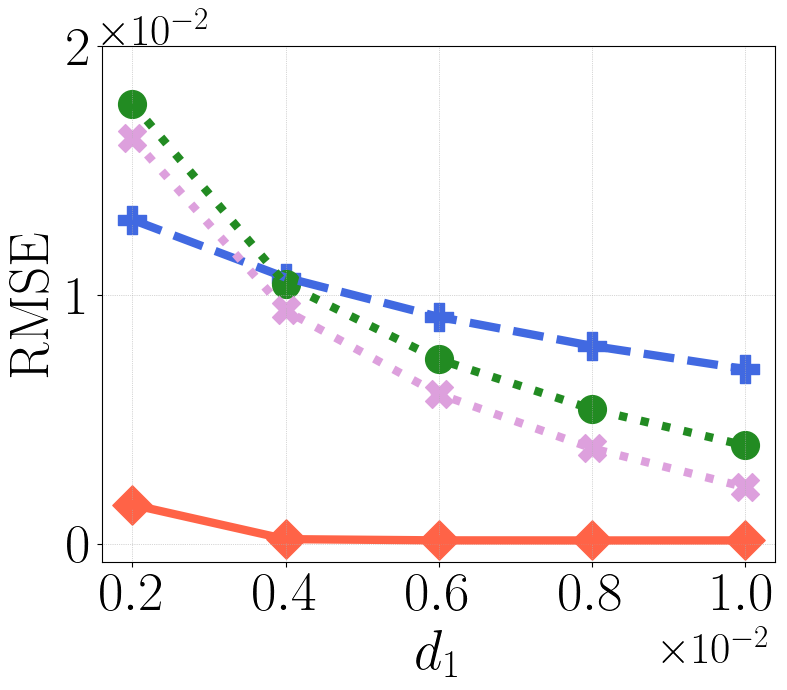

In [6]:
p = [0.002, 0.004, 0.006, 0.008, 0.01]
alt_GD_rmse = np.array([0.0637624, 0.0638032, 0.0633438, 0.0577999, 0.0481980])
softimpute_als_rmse = np.array([0.0130069, 0.0106883, 0.0091079, 0.0079454, 0.0070123])
nuclear_reg_rmse = np.array([0.0176732, 0.0104306, 0.0073992, 0.0054061, 0.0039429])
iipw_1_rmse = np.array([0.0162836, 0.0093657, 0.0060119, 0.0038322, 0.0022689])
iipw_rmse = np.array([0.0015607, 0.0001787, 0.0001298, 0.0001265, 0.0001275])

variables = ['p', 'alt_GD_rmse', 'softimpute_als_rmse', 'nuclear_reg_rmse', 'iipw_1_rmse', 'iipw_rmse']

f, ax = plt.subplots(figsize=(8,7))
print(softimpute_als_rmse)
#plt.plot(p, alt_GD_rmse, lw=4, color='royalblue',ls="dotted" )
plt.plot(p, softimpute_als_rmse, lw=6, color='royalblue', ls="dashed")
plt.plot(p, nuclear_reg_rmse, lw=6, color='forestgreen', ls="dotted")
plt.plot(p, iipw_1_rmse, lw=6, color='plum', ls="dotted")
plt.plot(p, iipw_rmse, color='tomato',lw=6)

#plt.scatter(p, alt_GD_rmse, s=400, color='royalblue', label=r"$\widehat{T}$", marker="X")
plt.scatter(p, softimpute_als_rmse, s=400, color='royalblue', label=r"$\mathrm{SoftImpute}$"+"\n"+r"$\mathrm{ALS}$", marker="P")
plt.scatter(p, nuclear_reg_rmse, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
plt.scatter(p, iipw_1_rmse, s=400, color='plum', label=r"$\mathrm{Alg.~1~(1~step)}$", marker="X")
plt.scatter(p, iipw_rmse, s=400, color='tomato', label=r"$\mathrm{Alg.~1}$", marker="D")

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

xticks = [0].extend(p)
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
ax.set_xticks(p)
ax.xaxis.get_offset_text().set_fontsize(32)


plt.yticks(fontsize=40)
#plt.yscale('log')
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
ax.set_yticks([0,1e-2, 2e-2])
ax.yaxis.get_offset_text().set_fontsize(32)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"uniform_sampling_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()